In [ ]:
from dotenv import load_dotenv
load_dotenv()


In [ ]:
from langchain.chat_models import init_chat_model

In [ ]:
from typing import TypedDict, Annotated
from langgraph.constants import END
from langgraph.constants import START
from langgraph.graph import StateGraph, add_messages

llm = init_chat_model("google_genai:gemini-3.6-flash")

class State(TypedDict):
    messages: Annotated[list, add_messages]

def chatbot(state: State) -> State:
    return {
        "messages": [llm.invoke(state["messages"])]
    }

builder = StateGraph(State)

builder.add_node("chatbot_node", chatbot)

builder.add_edge(START, "chatbot_node")
builder.add_edge("chatbot_node", END)

graph = builder.compile()

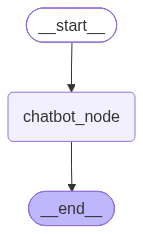

In [24]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
message = {"role": "user", "content": "Who walked on the moon first time? Print only  the name"}
response = graph.invoke({"messages": [message]})

response["messages"]


In [ ]:
state = None

while True:
    in_message = input("You: ")
    if in_message.lower() in ["exit", "quit", "stop", "stop chatting"]:
        break
    if state is None:
        state: State = {
            "messages": [{"role": "user", "content": in_message}],
        }
    else:
        state["messages"].append({"role": "user", "content": in_message})

    state = graph.invoke(state)
    print("Bot:", state["messages"][-1].content )